## K-Means Clustering

`K-Means` is an **unsupervised machine learning algorithm**
used to **group data into clusters** based on similarity.
Unlike supervised models, it does **not use labeled data**.

The goal of K-Means is to group similar data points together.

---

### What It Is

K-Means:
- Divides data into **K clusters**
- Each cluster has a center called a **centroid**
- Assigns each data point to the nearest centroid
- Updates centroids until clusters stabilize

---

### Why It Is Used

K-Means is used because:
- It is simple and easy to understand
- Works well for grouping similar data
- Is fast and scalable
- Requires no labeled data

---

### Where It Is Used

K-Means is commonly used in:
- Customer segmentation
- Market analysis
- Image compression
- Document clustering
- Pattern discovery

---

### When It Performs Well

K-Means performs well when:
- Clusters are well-separated
- Data is numerical and scaled
- Clusters are roughly spherical
- Dataset is medium to large

---

### When It Performs Poorly

K-Means performs poorly when:
- Clusters overlap heavily
- Data has outliers
- Clusters have different sizes or densities
- Features are not scaled

---

### Advantages

- Simple and fast
- Easy to implement
- Scales well to large datasets
- Easy to visualize (in low dimensions)

---

### Limitations

- Requires choosing K in advance
- Sensitive to initial centroid placement
- Sensitive to outliers
- Assumes clusters are spherical

---

### Key Takeaways

- K-Means groups similar data points
- Works without labeled data
- Feature scaling is important
- Best for well-separated clusters


In [1]:
import numpy as np


### Euclidean Distance

In [2]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


### Initialize Centroids

In [3]:
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]


### Assign Clusters

In [4]:
def assign_clusters(X, centroids):
    clusters = []
    
    for x in X:
        distances = [euclidean_distance(x, c) for c in centroids]
        cluster_idx = np.argmin(distances)
        clusters.append(cluster_idx)
        
    return np.array(clusters)


### Update Centroids

In [5]:
def update_centroids(X, clusters, k):
    new_centroids = []
    
    for i in range(k):
        cluster_points = X[clusters == i]
        
        if len(cluster_points) == 0:
            continue
        
        centroid = np.mean(cluster_points, axis=0)
        new_centroids.append(centroid)
        
    return np.array(new_centroids)


### K-Means Algorithm (Main Loop)

In [6]:
def kmeans(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, k)
    
    for _ in range(max_iters):
        clusters = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, clusters, k)
        
        # Convergence check
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        
        centroids = new_centroids
        
    return clusters, centroids


### Inertia (for Elbow Method)

In [8]:
def inertia(X, clusters, centroids):
    total = 0
    for i, x in enumerate(X):
        total += euclidean_distance(x, centroids[clusters[i]]) ** 2
    return total


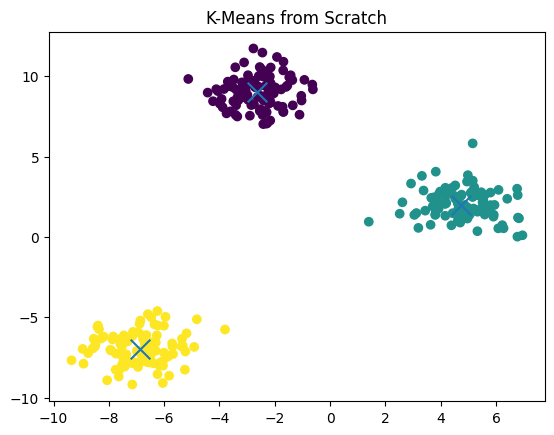

In [9]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

clusters, centroids = kmeans(X, k=3)

plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200)
plt.title("K-Means from Scratch")
plt.show()
